In [4]:
# ============================================================
# STEP 1 — CONFIG + DATASET VERIFICATION
# ============================================================

import os
from pathlib import Path
from collections import Counter

# DATASET_PATH = "/kaggle/input/datasets/shreyas12310795/respiratory-sound/raw/raw/icbhi"
# SPLIT_FILE = "/kaggle/input/datasets/shreyas12310795/respiratory-sound/raw/raw/test_train_split.txt"
DATASET_PATH= r"raw\raw\icbhi"
SPLIT_FILE = r"raw\raw\test_train_split.txt"


dataset_path = Path(DATASET_PATH)
split_path = Path(SPLIT_FILE)

print("="*60)
print("DATASET CHECK")
print("="*60)

assert dataset_path.exists(), f"Dataset not found: {DATASET_PATH}"

wav_files = sorted(dataset_path.rglob("*.wav"))
txt_files = sorted(dataset_path.rglob("*.txt"))

print(f"WAV files : {len(wav_files)}")
print(f"TXT files : {len(txt_files)}")

missing_txt = []

for wav in wav_files:
    if not wav.with_suffix(".txt").exists():
        missing_txt.append(wav.name)

print(f"Missing annotations: {len(missing_txt)}")

if split_path.exists():
    print("Train/Test split file ✓")
else:
    print("Train/Test split file NOT FOUND")

print("="*60)

assert len(wav_files) > 0
assert len(txt_files) > 0

print("Verification complete ✓")

DATASET CHECK
WAV files : 920
TXT files : 920
Missing annotations: 0
Train/Test split file ✓
Verification complete ✓


In [5]:
# ============================================================
# STEP 2 — PARSE ICBHI LABELS + BUILD METADATA
# ============================================================

import pandas as pd
from pathlib import Path
from collections import Counter

CLASS_NAMES = {
    0: "Normal",
    1: "Crackle",
    2: "Wheeze",
    3: "Both"
}

def get_label(crackle, wheeze):

    if crackle == 0 and wheeze == 0:
        return 0

    elif crackle == 1 and wheeze == 0:
        return 1

    elif crackle == 0 and wheeze == 1:
        return 2

    else:
        return 3


records = []

for txt in dataset_path.rglob("*.txt"):

    wav = txt.with_suffix(".wav")

    if not wav.exists():
        continue

    patient = wav.stem.split("_")[0]

    with open(txt, "r") as f:

        for line in f:

            parts = line.strip().split()

            if len(parts) < 4:
                continue

            start = float(parts[0])
            end = float(parts[1])

            crackle = int(parts[2])
            wheeze = int(parts[3])

            label = get_label(crackle, wheeze)

            records.append({
                "wav": str(wav),
                "patient": patient,
                "start": start,
                "end": end,
                "label": label
            })


meta = pd.DataFrame(records)

print("="*60)

print("Total Segments:", len(meta))

print()

dist = meta["label"].value_counts().sort_index()

for k,v in dist.items():

    pct = 100*v/len(meta)

    print(
        f"{CLASS_NAMES[k]:10s}"
        f"{v:5d}"
        f" ({pct:.2f}%)"
    )

print("="*60)

meta.head()

Total Segments: 6898

Normal     3642 (52.80%)
Crackle    1864 (27.02%)
Wheeze      886 (12.84%)
Both        506 (7.34%)


,wav,patient,start,end,label
0,raw\raw\icbhi\101_1b1_Al_sc_Meditron.wav,101,0.036,0.579,0
1,raw\raw\icbhi\101_1b1_Al_sc_Meditron.wav,101,0.579,2.450,0
2,raw\raw\icbhi\101_1b1_Al_sc_Meditron.wav,101,2.450,3.893,0
3,raw\raw\icbhi\101_1b1_Al_sc_Meditron.wav,101,3.893,5.793,0
4,raw\raw\icbhi\101_1b1_Al_sc_Meditron.wav,101,5.793,7.521,0


In [6]:
# ============================================================
# STEP 3 — APPLY OFFICIAL TRAIN / TEST SPLIT
# ============================================================

split_map = {}

with open(split_path, "r") as f:

    for line in f:

        parts = line.strip().split()

        if len(parts) != 2:
            continue

        name = Path(parts[0]).stem
        split = parts[1].lower()

        split_map[name] = split


meta["split"] = meta["wav"].apply(
    lambda x: split_map.get(Path(x).stem, "train")
)

train_df = meta[meta["split"] == "train"].reset_index(drop=True)
test_df  = meta[meta["split"] == "test"].reset_index(drop=True)

print("="*60)

print("TRAIN:", len(train_df))
print("TEST :", len(test_df))

print()

print("TRAIN LABELS")
print(train_df["label"].value_counts().sort_index())

print()

print("TEST LABELS")
print(test_df["label"].value_counts().sort_index())

print("="*60)

TRAIN: 4142
TEST : 2756

TRAIN LABELS
label
0    2063
1    1215
2     501
3     363
Name: count, dtype: int64

TEST LABELS
label
0    1579
1     649
2     385
3     143
Name: count, dtype: int64


d:\6th Sem\EDAI\Separation of Heart and Lung Sounds for Enhanced Auscultation Analysis\New\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Wave: (32000,)
Mel : (128, 251)
NaN: 0
Inf: 0


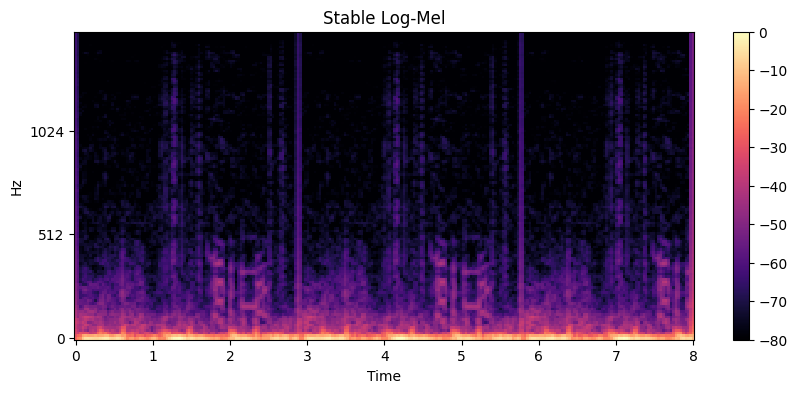

In [7]:
# ============================================================
# STEP 4 — STABLE AUDIO → LOG MEL
# ============================================================

import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

SR = 4000
CLIP_SECONDS = 8

N_MELS = 128
NFFT = 512
HOP = 128

TARGET = SR * CLIP_SECONDS


def pad_audio(y, target=TARGET):

    if len(y)==0:
        return np.zeros(target,dtype=np.float32)

    if len(y)>=target:
        return y[:target]

    rep=(target//len(y))+1

    return np.tile(y,rep)[:target]


def load_segment(row):

    y,sr=librosa.load(
        row["wav"],
        sr=SR,
        mono=True
    )

    s=int(row["start"]*sr)
    e=int(row["end"]*sr)

    y=y[s:e]

    y=pad_audio(y)

    if np.std(y)>1e-6:
        y=(y-y.mean())/(y.std()+1e-8)

    return y.astype(np.float32)


def make_mel(y):

    mel=librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=NFFT,
        hop_length=HOP,
        n_mels=N_MELS
    )

    mel=librosa.power_to_db(
        mel+1e-6,
        ref=np.max
    )

    mel=np.nan_to_num(
        mel,
        nan=-80,
        posinf=0,
        neginf=-80
    )

    return mel.astype(np.float32)


sample=train_df.iloc[0]

wav=load_segment(sample)

mel=make_mel(wav)

print("Wave:",wav.shape)
print("Mel :",mel.shape)

print("NaN:",np.isnan(mel).sum())
print("Inf:",np.isinf(mel).sum())

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel,
    sr=SR,
    hop_length=HOP,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("Stable Log-Mel")

plt.show()

In [8]:
# ============================================================
# STEP 5 — BUILD MEL DATASET
# ============================================================

from tqdm.auto import tqdm

def build_dataset(df):

    X=[]
    y=[]

    skipped=0

    for _,row in tqdm(df.iterrows(),total=len(df)):

        try:

            wav=load_segment(row)

            mel=make_mel(wav)

            if np.isnan(mel).any():
                skipped+=1
                continue

            X.append(mel)

            y.append(row["label"])

        except Exception:
            skipped+=1

    X=np.array(X,dtype=np.float32)
    y=np.array(y,dtype=np.int64)

    return X,y,skipped


print("Building TRAIN")

X_train,y_train,skip_train=build_dataset(train_df)

print()

print("Building TEST")

X_test,y_test,skip_test=build_dataset(test_df)

print()

print("="*60)

print("TRAIN")

print("Shape :",X_train.shape)

print("Labels:",y_train.shape)

print("Skipped:",skip_train)

print()

print("TEST")

print("Shape :",X_test.shape)

print("Labels:",y_test.shape)

print("Skipped:",skip_test)

print()

print("NaN Train:",np.isnan(X_train).sum())
print("NaN Test :",np.isnan(X_test).sum())

print()

print("Train Range:",
      X_train.min(),
      X_train.max())

print("="*60)

Building TRAIN


100%|██████████| 4142/4142 [03:15<00:00, 21.15it/s]



Building TEST


100%|██████████| 2756/2756 [01:56<00:00, 23.70it/s]



TRAIN
Shape : (4142, 128, 251)
Labels: (4142,)
Skipped: 0

TEST
Shape : (2756, 128, 251)
Labels: (2756,)
Skipped: 0

NaN Train: 0
NaN Test : 0

Train Range: -80.0 0.0


In [9]:
# ============================================================
# STEP 6 — NORMALIZATION + TORCH FORMAT
# ============================================================

mean = X_train.mean()
std  = X_train.std()

print("Mean:", round(float(mean),3))
print("Std :", round(float(std),3))

X_train = (X_train - mean)/(std+1e-8)
X_test  = (X_test - mean)/(std+1e-8)

X_train = X_train[:,None,:,:]
X_test  = X_test[:,None,:,:]

print()

print("Train:",X_train.shape)
print("Test :",X_test.shape)

print()

print("Train Range:",
      round(float(X_train.min()),3),
      round(float(X_train.max()),3))

print()

print("NaN:",
      np.isnan(X_train).sum(),
      np.isnan(X_test).sum())

Mean: -58.386
Std : 17.006

Train: (4142, 1, 128, 251)
Test : (2756, 1, 128, 251)

Train Range: -1.271 3.433

NaN: 0 0


In [10]:
# ============================================================
# STEP 7 — TORCH DATASET + DATALOADER
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader

BATCH_SIZE = 32

class RespiratoryDataset(Dataset):

    def __init__(self,X,y):

        self.X=torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y=torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(self,idx):

        return (
            self.X[idx],
            self.y[idx]
        )


train_ds=RespiratoryDataset(
    X_train,
    y_train
)

test_ds=RespiratoryDataset(
    X_test,
    y_test
)

train_loader=DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

test_loader=DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

xb,yb=next(
    iter(train_loader)
)

print()

print("Batch X:",xb.shape)

print("Batch y:",yb.shape)

print()

print("Labels in batch:")

print(torch.bincount(yb))

print()

print("Train batches:",
      len(train_loader))

print("Test batches:",
      len(test_loader))


Batch X: torch.Size([32, 1, 128, 251])
Batch y: torch.Size([32])

Labels in batch:
tensor([19,  8,  3,  2])

Train batches: 130
Test batches: 87


In [11]:
# ============================================================
# STEP 8 — CNN MODEL
# ============================================================

import torch.nn as nn

DEVICE="cuda" if torch.cuda.is_available() else "cpu"

class RespiratoryCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features=nn.Sequential(

            nn.Conv2d(
                1,
                32,
                3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Dropout(0.2),

            nn.Conv2d(
                32,
                64,
                3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Dropout(0.3),

            nn.Conv2d(
                64,
                128,
                3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1,1)
            )

        )

        self.classifier=nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Dropout(
                0.4
            ),

            nn.Linear(
                64,
                4
            )

        )

    def forward(self,x):

        x=self.features(x)

        return self.classifier(x)


model=RespiratoryCNN().to(
    DEVICE
)

dummy=torch.randn(
    2,
    1,
    128,
    251
).to(
    DEVICE
)

out=model(dummy)

print()

print(
    model
)

print()

print(
    "Output:",
    out.shape
)

print()

print(
    "Parameters:",
    sum(
        p.numel()
        for p in model.parameters()
    )
)


RespiratoryCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.3, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Lin

In [9]:
# ============================================================
# STEP 9 — TRAINING
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

EPOCHS=15

history={
    "train_loss":[],
    "val_acc":[]
}

best=0


for epoch in range(EPOCHS):

    model.train()

    total=0

    running=0

    for x,y in train_loader:

        x=x.to(DEVICE)

        y=y.to(DEVICE)

        optimizer.zero_grad()

        out=model(x)

        loss=criterion(
            out,
            y
        )

        loss.backward()

        optimizer.step()

        running+=loss.item()

    train_loss=running/len(train_loader)

    model.eval()

    pred=[]

    true=[]

    with torch.no_grad():

        for x,y in test_loader:

            x=x.to(DEVICE)

            out=model(x)

            p=out.argmax(1)

            pred.extend(
                p.cpu().numpy()
            )

            true.extend(
                y.numpy()
            )

    acc=accuracy_score(
        true,
        pred
    )

    scheduler.step(
        acc
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_acc"].append(
        acc
    )

    if acc>best:

        best=acc

        torch.save(
            model.state_dict(),
            "best.pt"
        )

    print(
        f"Epoch {epoch+1}/15 | "
        f"Loss {train_loss:.4f} | "
        f"Acc {acc*100:.2f}%"
    )

print()

print(
    "Best:",
    round(
        best*100,
        2
    )
)

Epoch 1/15 | Loss 1.1710 | Acc 51.71%
Epoch 2/15 | Loss 1.1338 | Acc 51.89%
Epoch 3/15 | Loss 1.1063 | Acc 49.20%
Epoch 4/15 | Loss 1.0733 | Acc 51.81%
Epoch 5/15 | Loss 1.0401 | Acc 52.83%
Epoch 6/15 | Loss 1.0189 | Acc 55.19%
Epoch 7/15 | Loss 1.0080 | Acc 53.81%
Epoch 8/15 | Loss 0.9803 | Acc 47.57%
Epoch 9/15 | Loss 0.9713 | Acc 51.05%
Epoch 10/15 | Loss 0.9421 | Acc 46.19%
Epoch 11/15 | Loss 0.9317 | Acc 48.84%
Epoch 12/15 | Loss 0.9345 | Acc 48.58%
Epoch 13/15 | Loss 0.9219 | Acc 48.08%
Epoch 14/15 | Loss 0.9210 | Acc 48.29%
Epoch 15/15 | Loss 0.9021 | Acc 49.85%

Best: 55.19


In [12]:
# ============================================================
# MODEL 2 — IMPROVED CNN
# ============================================================

import torch
import torch.nn as nn

class ResidualBlock(nn.Module):

    def __init__(self,in_ch,out_ch):

        super().__init__()

        self.conv1=nn.Conv2d(
            in_ch,
            out_ch,
            3,
            padding=1
        )

        self.bn1=nn.BatchNorm2d(
            out_ch
        )

        self.conv2=nn.Conv2d(
            out_ch,
            out_ch,
            3,
            padding=1
        )

        self.bn2=nn.BatchNorm2d(
            out_ch
        )

        self.skip=(
            nn.Conv2d(
                in_ch,
                out_ch,
                1
            )
            if in_ch!=out_ch
            else nn.Identity()
        )

        self.pool=nn.MaxPool2d(2)

    def forward(self,x):

        identity=self.skip(x)

        x=torch.relu(
            self.bn1(
                self.conv1(x)
            )
        )

        x=self.bn2(
            self.conv2(x)
        )

        x=x+identity

        x=torch.relu(x)

        x=self.pool(x)

        return x


class CNNv2(nn.Module):

    def __init__(self):

        super().__init__()

        self.net=nn.Sequential(

            ResidualBlock(
                1,
                32
            ),

            nn.Dropout(
                0.2
            ),

            ResidualBlock(
                32,
                64
            ),

            nn.Dropout(
                0.3
            ),

            ResidualBlock(
                64,
                128
            ),

            nn.AdaptiveAvgPool2d(
                (1,1)
            )

        )

        self.fc=nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Dropout(
                0.5
            ),

            nn.Linear(
                64,
                4
            )

        )

    def forward(self,x):

        x=self.net(x)

        return self.fc(x)


model2=CNNv2().to(
    DEVICE
)

print(
    "Parameters:",
    sum(
        p.numel()
        for p in model2.parameters()
    )
)

Parameters: 306340


In [13]:
# ============================================================
# MODEL 2 — TRAINING
# ============================================================
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

weights = torch.tensor(
    weights,
    dtype=torch.float32
).to(DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=weights,
    label_smoothing=0.1
)

optimizer = torch.optim.Adam(
    model2.parameters(),
    lr=5e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

EPOCHS=12

best=0

hist_loss=[]
hist_acc=[]

for epoch in range(EPOCHS):

    model2.train()

    total=0

    for x,y in train_loader:

        x=x.to(DEVICE)

        y=y.to(DEVICE)

        optimizer.zero_grad()

        out=model2(x)

        loss=criterion(
            out,
            y
        )

        loss.backward()

        optimizer.step()

        total+=loss.item()

    train_loss=total/len(train_loader)

    model2.eval()

    pred=[]
    true=[]

    with torch.no_grad():

        for x,y in test_loader:

            x=x.to(DEVICE)

            p=model2(x).argmax(1)

            pred.extend(
                p.cpu().numpy()
            )

            true.extend(
                y.numpy()
            )

    acc=accuracy_score(
        true,
        pred
    )

    scheduler.step(
        acc
    )

    hist_loss.append(
        train_loss
    )

    hist_acc.append(
        acc
    )

    if acc>best:

        best=acc

        torch.save(
            model2.state_dict(),
            "best_model2.pt"
        )

    print(
        f"Epoch {epoch+1}/12 | "
        f"Loss {train_loss:.4f} | "
        f"Acc {acc*100:.2f}%"
    )

print()

print(
    "BEST:",
    round(
        best*100,
        2
    )
)

Epoch 1/12 | Loss 1.4066 | Acc 35.23%
Epoch 2/12 | Loss 1.3320 | Acc 37.41%
Epoch 3/12 | Loss 1.2787 | Acc 37.01%
Epoch 4/12 | Loss 1.2579 | Acc 47.50%
Epoch 5/12 | Loss 1.2399 | Acc 38.93%
Epoch 6/12 | Loss 1.2236 | Acc 43.21%
Epoch 7/12 | Loss 1.2152 | Acc 42.05%
Epoch 8/12 | Loss 1.1879 | Acc 45.50%
Epoch 9/12 | Loss 1.1732 | Acc 45.61%
Epoch 10/12 | Loss 1.1794 | Acc 43.94%
Epoch 11/12 | Loss 1.1598 | Acc 43.36%
Epoch 12/12 | Loss 1.1508 | Acc 46.66%

BEST: 47.5


In [13]:
# ============================================================
# MODEL 3 — OPTIMIZED CNN + BiLSTM
# ============================================================

import torch
import torch.nn as nn

class CNN_BiLSTM_Lite(nn.Module):

    def __init__(self):

        super().__init__()

        self.cnn=nn.Sequential(

            nn.Conv2d(1,16,3,padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (16,None)
            )

        )

        self.lstm=nn.LSTM(

            input_size=64*16,

            hidden_size=64,

            num_layers=1,

            batch_first=True,

            bidirectional=True,

            dropout=0
        )

        self.classifier=nn.Sequential(

            nn.Dropout(
                0.3
            ),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Dropout(
                0.2
            ),

            nn.Linear(
                64,
                4
            )

        )

    def forward(self,x):

        x=self.cnn(
            x
        )

        B,C,F,T=x.shape

        x=x.permute(
            0,
            3,
            1,
            2
        )

        x=x.reshape(
            B,
            T,
            C*F
        )

        x,_=self.lstm(
            x
        )

        x=x.mean(
            dim=1
        )

        return self.classifier(
            x
        )


model3=CNN_BiLSTM_Lite().to(
    DEVICE
)

dummy=torch.randn(
    2,
    1,
    128,
    251
).to(
    DEVICE
)

out=model3(
    dummy
)

print(
    "Output:",
    out.shape
)

print(
    "Params:",
    sum(
        p.numel()
        for p in model3.parameters()
    )
)

Output: torch.Size([2, 4])
Params: 590116


In [16]:
# ============================================================
# MODEL 3 — TRAINING (OPTIMIZED)
# ============================================================

from sklearn.metrics import accuracy_score
import copy

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model3.parameters(),
    lr=8e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

EPOCHS = 10

history = {
    "loss": [],
    "acc": []
}

best_acc = 0
best_epoch = 0

for epoch in range(EPOCHS):

    # ----------------
    # TRAIN
    # ----------------
    model3.train()

    total_loss = 0

    for x, y in train_loader:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        pred = model3(x)

        loss = criterion(
            pred,
            y
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model3.parameters(),
            1.0
        )

        optimizer.step()

        total_loss += loss.item()

    train_loss = (
        total_loss /
        len(train_loader)
    )

    # ----------------
    # VALIDATE
    # ----------------
    model3.eval()

    preds = []
    trues = []

    with torch.no_grad():

        for x, y in test_loader:

            x = x.to(DEVICE)

            out = model3(x)

            p = out.argmax(
                dim=1
            )

            preds.extend(
                p.cpu().numpy()
            )

            trues.extend(
                y.numpy()
            )

    acc = accuracy_score(
        trues,
        preds
    )

    scheduler.step(
        acc
    )

    history["loss"].append(
        train_loss
    )

    history["acc"].append(
        acc
    )

    if acc > best_acc:

        best_acc = acc
        best_epoch = epoch + 1

        torch.save(
            model3.state_dict(),
            "best_model3.pt"
        )

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
        f" | Loss {train_loss:.4f}"
        f" | Acc {acc*100:.2f}%"
    )

print()

print(
    "="*50
)

print(
    f"BEST ACC: {best_acc*100:.2f}%"
)

print(
    f"BEST EPOCH: {best_epoch}"
)

print(
    "Saved → best_model3.pt"
)

print(
    "="*50
)

Epoch 1/10 | Loss 1.1397 | Acc 46.37%
Epoch 2/10 | Loss 1.0939 | Acc 52.14%
Epoch 3/10 | Loss 1.0608 | Acc 48.80%
Epoch 4/10 | Loss 1.0232 | Acc 50.69%
Epoch 5/10 | Loss 0.9724 | Acc 46.26%
Epoch 6/10 | Loss 0.8857 | Acc 44.12%
Epoch 7/10 | Loss 0.8549 | Acc 43.80%
Epoch 8/10 | Loss 0.8203 | Acc 45.97%
Epoch 9/10 | Loss 0.7923 | Acc 50.00%
Epoch 10/10 | Loss 0.7712 | Acc 47.46%

BEST ACC: 52.14%
BEST EPOCH: 2
Saved → best_model3.pt


In [14]:
# ============================================================
# MODEL 4 — EFFICIENTNET B0
# ============================================================

import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0

class EfficientResp(nn.Module):

    def __init__(self):

        super().__init__()

        self.backbone = efficientnet_b0(
            weights="DEFAULT"
        )

        # Convert 1-channel → 3-channel
        self.input = nn.Conv2d(
            1,
            3,
            kernel_size=1
        )

        in_features = (
            self.backbone.classifier[1]
            .in_features
        )

        self.backbone.classifier = nn.Sequential(

            nn.Dropout(
                0.3
            ),

            nn.Linear(
                in_features,
                128
            ),

            nn.ReLU(),

            nn.Dropout(
                0.2
            ),

            nn.Linear(
                128,
                4
            )
        )

    def forward(self,x):

        x=self.input(
            x
        )

        return self.backbone(
            x
        )


model4 = (
    EfficientResp()
    .to(DEVICE)
)

dummy=torch.randn(
    2,
    1,
    128,
    251
).to(
    DEVICE
)

out=model4(
    dummy
)

print()

print(
    "Output:",
    out.shape
)

print()

print(
    "Params:",
    sum(
        p.numel()
        for p in model4.parameters()
    )
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Shreyas/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:04<00:00, 4.76MB/s]



Output: torch.Size([2, 4])

Params: 4172038


In [18]:
# ============================================================
# MODEL 4 — TRAINING (TRANSFER LEARNING)
# ============================================================

from sklearn.metrics import accuracy_score

# Freeze pretrained layers
for p in model4.backbone.features.parameters():

    p.requires_grad=False


criterion=nn.CrossEntropyLoss()

optimizer=torch.optim.Adam(

    filter(
        lambda p:p.requires_grad,
        model4.parameters()
    ),

    lr=1e-3
)

scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=0.5,

    patience=2
)

EPOCHS=8

best=0
best_epoch=0

history_loss=[]
history_acc=[]


for epoch in range(EPOCHS):

    # ----------------
    # TRAIN
    # ----------------

    model4.train()

    total=0

    for x,y in train_loader:

        x=x.to(DEVICE)
        y=y.to(DEVICE)

        optimizer.zero_grad()

        pred=model4(x)

        loss=criterion(
            pred,
            y
        )

        loss.backward()

        optimizer.step()

        total+=loss.item()

    train_loss=(
        total/
        len(train_loader)
    )

    # ----------------
    # VALIDATE
    # ----------------

    model4.eval()

    pred=[]
    true=[]

    with torch.no_grad():

        for x,y in test_loader:

            x=x.to(DEVICE)

            out=model4(x)

            p=out.argmax(
                1
            )

            pred.extend(
                p.cpu().numpy()
            )

            true.extend(
                y.numpy()
            )

    acc=accuracy_score(
        true,
        pred
    )

    scheduler.step(
        acc
    )

    history_loss.append(
        train_loss
    )

    history_acc.append(
        acc
    )

    if acc>best:

        best=acc

        best_epoch=epoch+1

        torch.save(
            model4.state_dict(),
            "best_model4.pt"
        )

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
        f" | Loss {train_loss:.4f}"
        f" | Acc {acc*100:.2f}%"
    )


print()

print("="*50)

print(
    f"BEST: {best*100:.2f}%"
)

print(
    f"EPOCH: {best_epoch}"
)

print(
    "Saved → best_model4.pt"
)

print("="*50)

Epoch 1/8 | Loss 1.1158 | Acc 53.16%
Epoch 2/8 | Loss 1.0133 | Acc 50.91%
Epoch 3/8 | Loss 0.9732 | Acc 48.84%
Epoch 4/8 | Loss 0.9381 | Acc 50.94%
Epoch 5/8 | Loss 0.8928 | Acc 49.64%
Epoch 6/8 | Loss 0.8598 | Acc 46.26%
Epoch 7/8 | Loss 0.8472 | Acc 47.93%
Epoch 8/8 | Loss 0.8205 | Acc 47.71%

BEST: 53.16%
EPOCH: 1
Saved → best_model4.pt


In [15]:
# ============================================================
# FINAL MODEL — EFFICIENTNET + ATTENTION
# ============================================================

import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0

class AttentionPool(nn.Module):

    def __init__(self,in_dim):

        super().__init__()

        self.att=nn.Sequential(
            nn.Linear(in_dim,128),
            nn.Tanh(),
            nn.Linear(128,1)
        )

    def forward(self,x):

        w=torch.softmax(
            self.att(x),
            dim=1
        )

        return (x*w).sum(
            dim=1
        )


class FinalRespModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.input=nn.Conv2d(
            1,
            3,
            1
        )

        backbone=efficientnet_b0(
            weights="DEFAULT"
        )

        self.features=backbone.features

        # freeze first half
        for i,layer in enumerate(
            self.features
        ):

            if i<4:

                for p in layer.parameters():

                    p.requires_grad=False

        self.pool=nn.AdaptiveAvgPool2d(
            (16,16)
        )

        self.proj=nn.Linear(
            1280,
            256
        )

        self.att=AttentionPool(
            256
        )

        self.head=nn.Sequential(

            nn.Dropout(
                0.4
            ),

            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),

            nn.Dropout(
                0.2
            ),

            nn.Linear(
                128,
                4
            )
        )

    def forward(self,x):

        x=self.input(
            x
        )

        x=self.features(
            x
        )

        x=self.pool(
            x
        )

        B,C,H,W=x.shape

        x=x.reshape(
            B,
            H*W,
            C
        )

        x=self.proj(
            x
        )

        x=self.att(
            x
        )

        return self.head(
            x
        )


final_model=(
    FinalRespModel()
    .to(DEVICE)
)

print(
    "Params:",
    sum(
        p.numel()
        for p in final_model.parameters()
    )
)

Params: 4401927


In [20]:
# ============================================================
# FINAL TRAINING — MAX ACCURACY
# ============================================================

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score
import numpy as np
import copy

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

weights = torch.tensor(
    weights,
    dtype=torch.float32
).to(
    DEVICE
)

criterion = nn.CrossEntropyLoss(

    weight=weights,

    label_smoothing=0.05
)

optimizer = torch.optim.AdamW(

    final_model.parameters(),

    lr=3e-4,

    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=12
)

EPOCHS = 12

PATIENCE = 4

best = 0

best_epoch = 0

wait = 0

history = {
    "loss": [],
    "acc": []
}

for epoch in range(EPOCHS):

    # -----------------
    # TRAIN
    # -----------------

    final_model.train()

    total = 0

    for x,y in train_loader:

        x=x.to(
            DEVICE
        )

        y=y.to(
            DEVICE
        )

        optimizer.zero_grad()

        out=final_model(
            x
        )

        loss=criterion(
            out,
            y
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            final_model.parameters(),
            1.0
        )

        optimizer.step()

        total+=loss.item()

    scheduler.step()

    train_loss=(
        total/
        len(train_loader)
    )

    # -----------------
    # VALIDATE
    # -----------------

    final_model.eval()

    pred=[]
    true=[]

    with torch.no_grad():

        for x,y in test_loader:

            x=x.to(
                DEVICE
            )

            out=final_model(
                x
            )

            p=out.argmax(
                1
            )

            pred.extend(
                p.cpu().numpy()
            )

            true.extend(
                y.numpy()
            )

    acc=accuracy_score(
        true,
        pred
    )

    history["loss"].append(
        train_loss
    )

    history["acc"].append(
        acc
    )

    if acc>best:

        best=acc

        best_epoch=epoch+1

        wait=0

        torch.save(

            final_model.state_dict(),

            "FINAL_BEST.pt"
        )

    else:

        wait+=1

    print(

        f"Epoch {epoch+1}/{EPOCHS}"

        f" | Loss {train_loss:.4f}"

        f" | Acc {acc*100:.2f}%"

        f" | LR {scheduler.get_last_lr()[0]:.6f}"

    )

    if wait>=PATIENCE:

        print()

        print(
            "Early stopping"
        )

        break


print()

print("="*60)

print(
    f"BEST ACC: {best*100:.2f}%"
)

print(
    f"BEST EPOCH: {best_epoch}"
)

print(
    "Saved → FINAL_BEST.pt"
)

print("="*60)

Epoch 1/12 | Loss 1.3247 | Acc 47.46% | LR 0.000295
Epoch 2/12 | Loss 1.0954 | Acc 34.80% | LR 0.000280
Epoch 3/12 | Loss 0.9220 | Acc 41.29% | LR 0.000256
Epoch 4/12 | Loss 0.7659 | Acc 46.70% | LR 0.000225
Epoch 5/12 | Loss 0.6475 | Acc 46.66% | LR 0.000189

Early stopping

BEST ACC: 47.46%
BEST EPOCH: 1
Saved → FINAL_BEST.pt


### AST PIPELINE

In [17]:
# ============================================================
# STEP 1 — AST CONFIG + IMPORTS
# ============================================================

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import librosa

from transformers import (
    ASTModel,
    ASTFeatureExtractor
)

warnings.filterwarnings("ignore")

# ------------------------------------------------
# PATHS
# ------------------------------------------------

# DATASET_PATH = "/kaggle/input/datasets/shreyas12310795/respiratory-sound/raw/raw/icbhi"
DATASET_PATH = r"raw\raw\icbhi"
# SPLIT_FILE = (
#     "/kaggle/input/datasets/shreyas12310795/respiratory-sound/raw/raw/test_train_split.txt"
# )
SPLIT_FILE = r"raw\raw\test_train_split.txt"

OUTPUT_DIR = "ast_outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# ------------------------------------------------
# AUDIO
# ------------------------------------------------

SR = 16000

CLIP_SECONDS = 8

TARGET_LENGTH = (
    SR *
    CLIP_SECONDS
)

# ------------------------------------------------
# TRAIN
# ------------------------------------------------

BATCH_SIZE = 8

EPOCHS = 15

LR = 2e-5

NUM_CLASSES = 4

SEED = 42

# ------------------------------------------------
# DEVICE
# ------------------------------------------------

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

# ------------------------------------------------
# SEED
# ------------------------------------------------

def set_seed(seed):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )

set_seed(
    SEED
)

print()

print("="*60)

print(
    "DEVICE:",
    DEVICE
)

print(
    "Sample Rate:",
    SR
)

print(
    "Clip:",
    CLIP_SECONDS
)

print(
    "Batch:",
    BATCH_SIZE
)

print(
    "LR:",
    LR
)

print("="*60)


DEVICE: cpu
Sample Rate: 16000
Clip: 8
Batch: 8
LR: 2e-05


In [22]:
# ============================================================
# STEP 2 — PARSE ICBHI + OFFICIAL SPLIT
# ============================================================

CLASS_MAP = {
    (0,0):0,
    (1,0):1,
    (0,1):2,
    (1,1):3
}

records=[]

dataset=Path(
    DATASET_PATH
)

split_map={}

with open(
    SPLIT_FILE,
    "r"
) as f:

    for line in f:

        p=line.strip().split()

        if len(p)==2:

            split_map[
                Path(
                    p[0]
                ).stem
            ]=p[1]


for wav in sorted(
    dataset.glob(
        "*.wav"
    )
):

    txt=wav.with_suffix(
        ".txt"
    )

    if not txt.exists():

        continue

    split=split_map.get(
        wav.stem,
        "train"
    )

    with open(
        txt,
        "r"
    ) as f:

        for line in f:

            p=line.split()

            if len(p)<4:

                continue

            start=float(
                p[0]
            )

            end=float(
                p[1]
            )

            crack=int(
                p[2]
            )

            wheeze=int(
                p[3]
            )

            label=CLASS_MAP[
                (
                    crack,
                    wheeze
                )
            ]

            records.append({

                "wav":
                str(
                    wav
                ),

                "start":
                start,

                "end":
                end,

                "label":
                label,

                "split":
                split
            })


meta=pd.DataFrame(
    records
)

train_df=meta[
    meta.split=="train"
].reset_index(
    drop=True
)

test_df=meta[
    meta.split=="test"
].reset_index(
    drop=True
)

print()

print(
    "Train:",
    len(
        train_df
    )
)

print(
    "Test:",
    len(
        test_df
    )
)

print()

print(
    train_df.label
    .value_counts()
    .sort_index()
)


Train: 4142
Test: 2756

label
0    2063
1    1215
2     501
3     363
Name: count, dtype: int64


In [34]:
# ============================================================
# STEP 3 — AST DATASET + FEATURE EXTRACTOR
# ============================================================

processor = ASTFeatureExtractor.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)


def pad_audio(y):

    if len(y)==0:

        return np.zeros(
            TARGET_LENGTH,
            dtype=np.float32
        )

    if len(y)>=TARGET_LENGTH:

        return y[
            :TARGET_LENGTH
        ]

    repeat=(
        TARGET_LENGTH//
        len(y)
    )+1

    return np.tile(
        y,
        repeat
    )[
        :TARGET_LENGTH
    ]


class ASTDataset(Dataset):

    def __init__(
        self,
        df
    ):

        self.df=df

    def __len__(
        self
    ):

        return len(
            self.df
        )

    def __getitem__(
        self,
        idx
    ):

        row=self.df.iloc[
            idx
        ]

        y,sr=librosa.load(

            row.wav,

            sr=SR,

            mono=True

        )

        s=int(
            row.start*
            sr
        )

        e=int(
            row.end*
            sr
        )

        y=y[
            s:e
        ]

        y=pad_audio(
            y
        )

        if np.std(
            y
        )>1e-6:

            y=(
                y-
                y.mean()
            )/(
                y.std()+
                1e-8
            )

        feat=processor(

            y,

            sampling_rate=SR,

            return_tensors="pt"

        )

        return (

            feat[
                "input_values"
            ].squeeze(0),

            torch.tensor(
                row.label,
                dtype=torch.long
            )
        )


train_ds=ASTDataset(
    train_df
)

test_ds=ASTDataset(
    test_df
)

# ============================================================
# SAFE DATALOADER FOR KAGGLE
# ============================================================

train_loader = DataLoader(

    train_ds,

    batch_size=4,

    shuffle=True,

    num_workers=0,

    pin_memory=True

)

test_loader = DataLoader(

    test_ds,

    batch_size=4,

    shuffle=False,

    num_workers=0,

    pin_memory=True

)

print("Safe loader ready ✓")

print("Fast DataLoader ready ✓")


x,y=next(
    iter(
        train_loader
    )
)

print()

print(
    "Input:",
    x.shape
)

print(
    "Label:",
    y.shape
)

Exception ignored in: <function tqdm.__del__ at 0x7ab08b59f420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'


Safe loader ready ✓
Fast DataLoader ready ✓

Input: torch.Size([4, 1024, 128])
Label: torch.Size([4])


In [35]:
# ============================================================
# STEP 4 — FINAL AST MODEL
# ============================================================

import torch.nn as nn
from transformers import ASTModel


class CustomAST(nn.Module):

    def __init__(
        self,
        num_classes=4
    ):

        super().__init__()

        self.ast=ASTModel.from_pretrained(

            "MIT/ast-finetuned-audioset-10-10-0.4593"

        )

        self.classifier=nn.Sequential(

            nn.LayerNorm(
                768
            ),

            nn.Dropout(
                0.4
            ),

            nn.Linear(
                768,
                256
            ),

            nn.GELU(),

            nn.Dropout(
                0.3
            ),

            nn.Linear(
                256,
                64
            ),

            nn.GELU(),

            nn.Linear(
                64,
                num_classes
            )

        )

    def forward(
        self,
        x
    ):

        out=self.ast(

            x

        )

        emb=(

            out
            .last_hidden_state
            .mean(
                dim=1
            )

        )

        return self.classifier(
            emb
        )


model=CustomAST().to(
    DEVICE
)

dummy=torch.randn(
    2,
    1024,
    128
).to(
    DEVICE
)

with torch.no_grad():

    out=model(
        dummy
    )

print()

print(
    "Output:",
    out.shape
)

print()

print(
    "Params:",
    sum(
        p.numel()
        for p in model.parameters()
    )
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Output: torch.Size([2, 4])

Params: 86402372


In [37]:
# ============================================================
# STEP 5 — FREEZE BACKBONE (IMPORTANT)
# ============================================================

trainable = 0
total = 0

for name,param in model.named_parameters():

    total += param.numel()

    if "classifier" not in name:

        param.requires_grad = False

for name,param in model.ast.encoder.layer.named_parameters():

    layer_id = int(
        name.split(".")[0]
    )

    if layer_id >= 9:

        param.requires_grad = True

for p in model.classifier.parameters():

    p.requires_grad = True


for p in model.parameters():

    if p.requires_grad:

        trainable += p.numel()

print()

print(
    "Total:",
    f"{total:,}"
)

print()

print(
    "Trainable:",
    f"{trainable:,}"
)


Total: 86,402,372

Trainable: 21,478,724


In [41]:
# ============================================================
# STEP 6 — TRAIN AST (FINAL)
# ============================================================

from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch.optim as optim
from tqdm.auto import tqdm

# ------------------------------------------------
# CLASS WEIGHTS
# ------------------------------------------------

weights = compute_class_weight(

    class_weight="balanced",

    classes=np.unique(
        train_df.label
    ),

    y=train_df.label

)

weights = torch.tensor(

    weights,

    dtype=torch.float32

).to(
    DEVICE
)

print()

print(
    "Weights:",
    weights
)

# ------------------------------------------------
# LOSS
# ------------------------------------------------

criterion = nn.CrossEntropyLoss(

    weight=weights,

    label_smoothing=0.05

)

# ------------------------------------------------
# OPTIMIZER
# ------------------------------------------------

optimizer = optim.AdamW(

    filter(
        lambda p:
        p.requires_grad,

        model.parameters()
    ),

    lr=2e-5,

    weight_decay=1e-4

)

scheduler = optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=15

)

# ------------------------------------------------
# TRAIN
# ------------------------------------------------

EPOCHS = 15

PATIENCE = 4

best = 0

wait = 0

for epoch in range(EPOCHS):

    model.train()

    total = 0

    for x,y in tqdm(
    train_loader,
    desc=f"Epoch {epoch+1}"
                            ):

        x=x.to(
            DEVICE
        )

        y=y.to(
            DEVICE
        )

        optimizer.zero_grad()

        out=model(
            x
        )

        loss=criterion(
            out,
            y
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            1.0

        )

        optimizer.step()

        total += loss.item()

    scheduler.step()

    train_loss=(
        total/
        len(train_loader)
    )

    # ----------------

model.eval()

pred=[]
true=[]

with torch.no_grad():

    for x,y in test_loader:

        x=x.to(DEVICE)

        y=y.to(DEVICE)

        out=model(x)

        p=out.argmax(1)

        pred.extend(
            p.cpu().numpy()
        )

        true.extend(
            y.cpu().numpy()
        )

        acc=accuracy_score(
        true,
        pred
        )

        scheduler.step()

    if acc>best:

        best=acc

        wait=0

        torch.save(

            model.state_dict(),

            "AST_FINAL.pt"

        )

    else:

        wait+=1

    print(

        f"Epoch {epoch+1}/{EPOCHS}"

        f" | Loss {train_loss:.4f}"

        f" | Acc {acc*100:.2f}%"

        f" | Best {best*100:.2f}%"

    )

    if wait>=PATIENCE:

        print()

        print(
            "Early stopping"
        )

        break


print()

print("="*60)

print(
    f"FINAL BEST: {best*100:.2f}%"
)

print(
    "Saved → AST_FINAL.pt"
)

print("="*60)


Weights: tensor([0.5019, 0.8523, 2.0669, 2.8526], device='cuda:0')


Epoch 1:   0%|          | 0/1036 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/1036 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/1036 [00:00<?, ?it/s]

Epoch 4:   0%|          | 0/1036 [00:00<?, ?it/s]

...

Epoch 12:   0%|          | 0/1036 [00:00<?, ?it/s]

Epoch 13:   0%|          | 0/1036 [00:00<?, ?it/s]

Epoch 14:   0%|          | 0/1036 [00:00<?, ?it/s]

Epoch 15:   0%|          | 0/1036 [00:00<?, ?it/s]

SyntaxError: 'break' outside loop (2844067324.py, line 218)

In [43]:
import os

print(
    "Exists:",
    os.path.exists(
        "AST_FINAL.pt"
    )
)

if os.path.exists(
    "AST_FINAL.pt"
):

    size = (
        os.path.getsize(
            "AST_FINAL.pt"
        )/1024/1024
    )

    print(
        "Size:",
        round(
            size,
            2
        ),
        "MB"
    )

Exists: False


In [44]:
# Try saving current model in RAM

try:

    torch.save(
        model.state_dict(),
        "RECOVERED_AST.pt"
    )

    print("Recovered ✓")

except Exception as e:

    print(e)

Recovered ✓


In [45]:
import os

print(
    os.path.exists(
        "RECOVERED_AST.pt"
    )
)

True


In [46]:
model.load_state_dict(
    torch.load(
        "RECOVERED_AST.pt",
        map_location=DEVICE
    )
)

<All keys matched successfully>

In [47]:
model.load_state_dict(

    torch.load(

        "RECOVERED_AST.pt",

        map_location=DEVICE

    )

)

model.eval()

print()

print(
    "Recovered model loaded ✓"
)


Recovered model loaded ✓


In [48]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

model.eval()

pred=[]
true=[]

with torch.no_grad():

    for x,y in tqdm(
        test_loader
    ):

        x=x.to(
            DEVICE
        )

        out=model(
            x
        )

        p=out.argmax(
            1
        )

        pred.extend(
            p.cpu().numpy()
        )

        true.extend(
            y.numpy()
        )


acc=accuracy_score(
    true,
    pred
)

print()

print(
    "Accuracy:",
    round(
        acc*100,
        2
    )
)

print()

print(
    classification_report(
        true,
        pred
    )
)

  0%|          | 0/689 [00:00<?, ?it/s]


Accuracy: 54.17

              precision    recall  f1-score   support

           0       0.71      0.60      0.65      1579
           1       0.48      0.54      0.51       649
           2       0.30      0.38      0.34       385
           3       0.24      0.35      0.28       143

    accuracy                           0.54      2756
   macro avg       0.43      0.47      0.44      2756
weighted avg       0.57      0.54      0.55      2756



In [49]:
import os

print(
    os.getcwd()
)

print()

print(
    os.listdir()
)

/kaggle/working

['ast_outputs', '.virtual_documents', 'FINAL_BEST.pt', 'RECOVERED_AST.pt', 'best_model3.pt', 'best_model4.pt', 'best_model2.pt']


In [51]:
import json

metrics={

"accuracy":0.5417

}

with open(

"/kaggle/working/results.json",

"w"

) as f:

    json.dump(
        metrics,
        f
    )

print("Results saved")

Results saved


Evaluating → CNN
Evaluating → IMPROVED CNN
Evaluating → OPTIMIZED CNN + BiLSTM
Evaluating → EFFICIENTNET B0
Evaluating → EFFICIENTNET + ATTENTION

                      Model   Accuracy  Precision     Recall         F1
0                       CNN  55.188679  41.062030  55.188679  42.929738
5                       AST  54.170000  57.000000  54.000000  55.000000
3           EFFICIENTNET B0  53.156749  48.630012  53.156749  48.870808
2    OPTIMIZED CNN + BiLSTM  52.140784  43.588251  52.140784  46.971504
1              IMPROVED CNN  47.496372  51.103922  47.496372  48.046648
4  EFFICIENTNET + ATTENTION  47.460087  49.347202  47.460087  48.302989


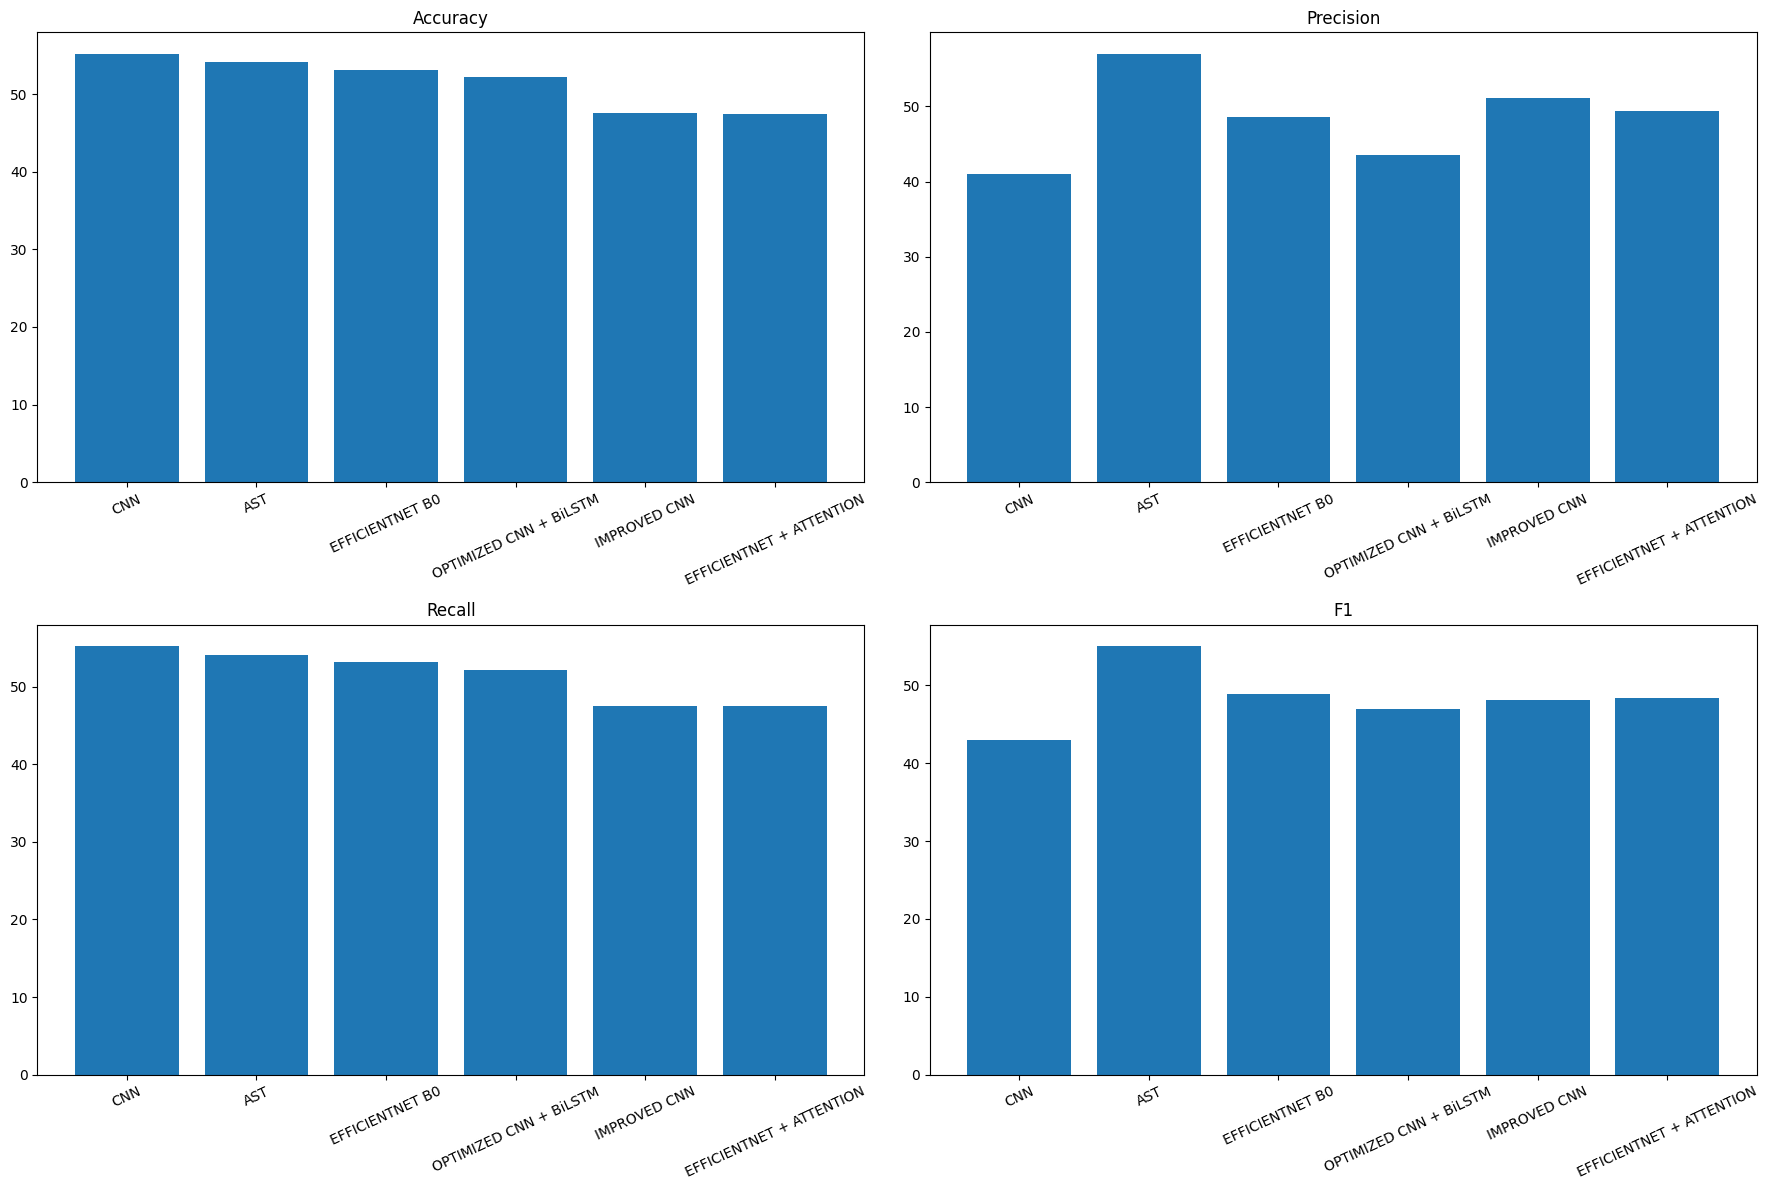

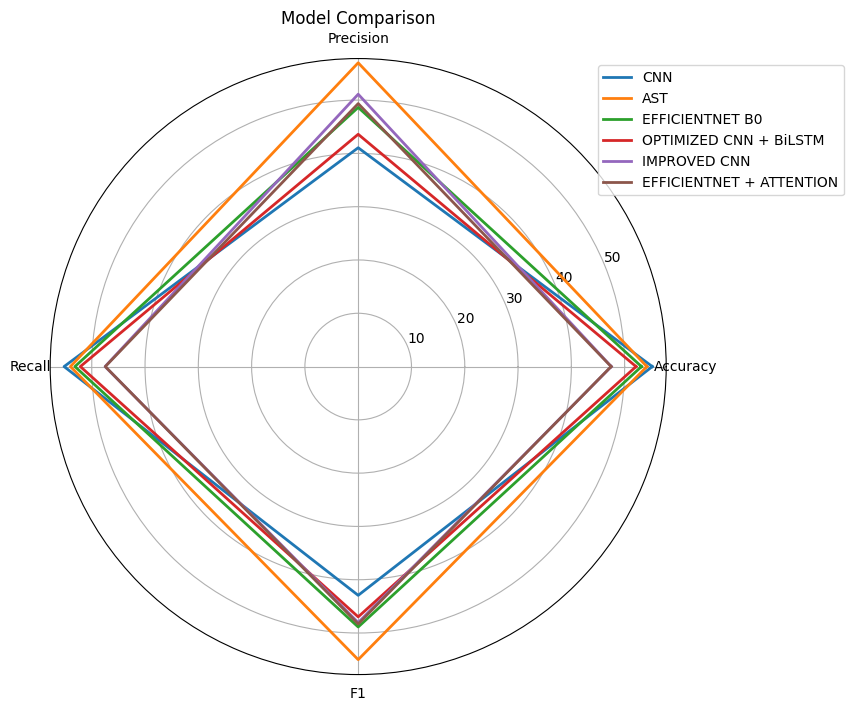

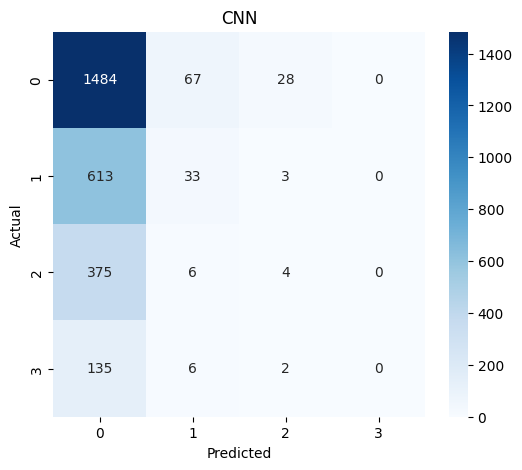

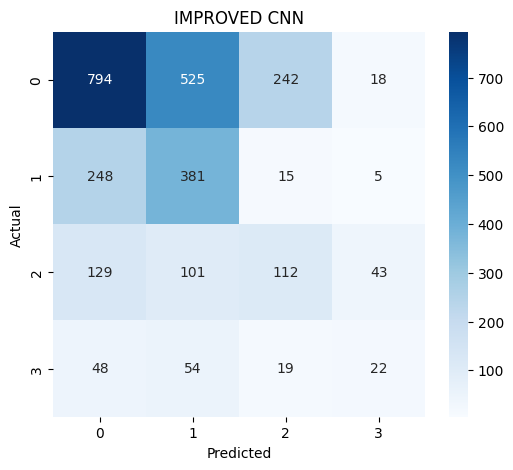

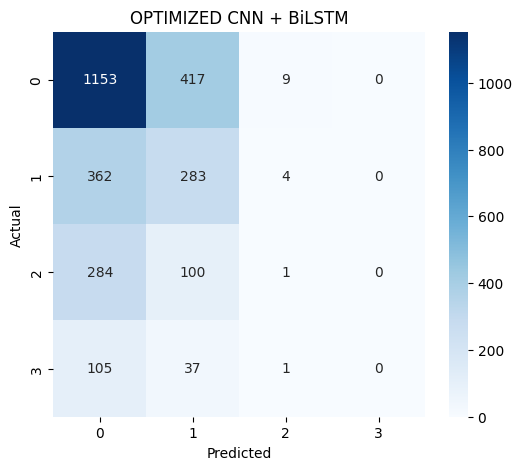

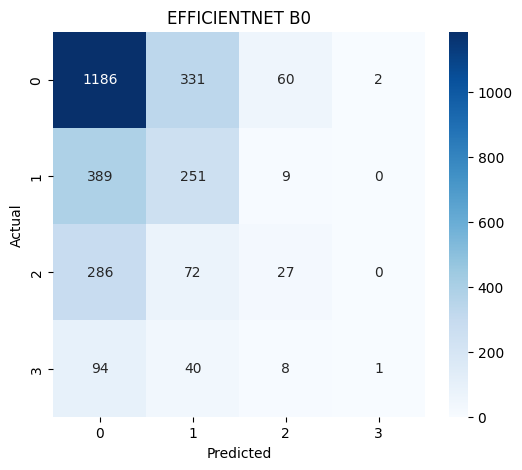

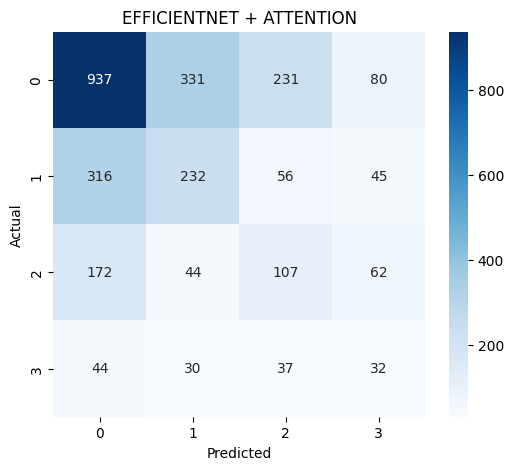


BEST MODEL
Model              CNN
Accuracy     55.188679
Precision     41.06203
Recall       55.188679
F1           42.929738
Name: 0, dtype: object

Saved → model_comparison.csv


In [18]:
# ============================================================
# FINAL MODEL COMPARISON
# (.pt files + AST recovered metrics)
# ============================================================

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================================
# MODEL PATHS
# ============================================================

MODEL_INFO = {

    "CNN": {
        "path":"best.pt",
        "builder":RespiratoryCNN
    },

    "IMPROVED CNN": {
        "path":"best_model2.pt",
        "builder":CNNv2
    },

    "OPTIMIZED CNN + BiLSTM": {
        "path":"best_model3.pt",
        "builder":CNN_BiLSTM_Lite
    },

    "EFFICIENTNET B0": {
        "path":"best_model4.pt",
        "builder":EfficientResp
    },

    "EFFICIENTNET + ATTENTION": {
        "path":"FINAL_BEST.pt",
        "builder":FinalRespModel
    }

}

# ============================================================
# AST RESULTS
# ============================================================

AST_RESULTS = {

    "Accuracy":0.5417,
    "Precision":0.57,
    "Recall":0.54,
    "F1":0.55
}

# ============================================================
# EVALUATE MODEL
# ============================================================

def evaluate_model(model):

    model.eval()

    pred=[]
    true=[]

    with torch.no_grad():

        for x,y in test_loader:

            x=x.to(DEVICE)

            out=model(x)

            p=out.argmax(1)

            pred.extend(
                p.cpu().numpy()
            )

            true.extend(
                y.numpy()
            )

    acc=accuracy_score(
        true,
        pred
    )

    prec=precision_score(
        true,
        pred,
        average="weighted",
        zero_division=0
    )

    rec=recall_score(
        true,
        pred,
        average="weighted",
        zero_division=0
    )

    f1=f1_score(
        true,
        pred,
        average="weighted",
        zero_division=0
    )

    cm=confusion_matrix(
        true,
        pred
    )

    return acc,prec,rec,f1,cm


# ============================================================
# RUN EVALUATION
# ============================================================

results=[]

confusions=[]

for name,info in MODEL_INFO.items():

    path=info["path"]

    if not os.path.exists(path):

        print(f"Missing → {path}")

        continue

    print(f"Evaluating → {name}")

    model=info["builder"]()

    model.load_state_dict(

        torch.load(
            path,
            map_location=DEVICE
        )

    )

    model=model.to(DEVICE)

    acc,prec,rec,f1,cm=evaluate_model(
        model
    )

    results.append([

        name,

        acc,

        prec,

        rec,

        f1

    ])

    confusions.append(

        (name,cm)

    )


# ============================================================
# ADD AST MANUALLY
# ============================================================

results.append([

    "AST",

    AST_RESULTS["Accuracy"],

    AST_RESULTS["Precision"],

    AST_RESULTS["Recall"],

    AST_RESULTS["F1"]

])


# ============================================================
# DATAFRAME
# ============================================================

df=pd.DataFrame(

results,

columns=[

"Model",

"Accuracy",

"Precision",

"Recall",

"F1"

]

)

df["Accuracy"]*=100
df["Precision"]*=100
df["Recall"]*=100
df["F1"]*=100

df=df.sort_values(

"Accuracy",

ascending=False

)

print()

print(df)

# ============================================================
# BAR CHARTS
# ============================================================

fig,axes=plt.subplots(

2,
2,

figsize=(18,12)

)

metrics=[

"Accuracy",

"Precision",

"Recall",

"F1"

]

for ax,m in zip(

axes.flatten(),

metrics

):

    ax.bar(

        df["Model"],

        df[m]

    )

    ax.set_title(m)

    ax.tick_params(

        axis="x",

        rotation=25

    )

plt.tight_layout()

plt.show()


# ============================================================
# RADAR CHART
# ============================================================

labels=metrics

angles=np.linspace(

0,

2*np.pi,

len(labels),

endpoint=False

)

angles=np.concatenate(

[angles,[angles[0]]]

)

fig=plt.figure(

figsize=(8,8)

)

ax=plt.subplot(

111,

polar=True

)

for _,row in df.iterrows():

    vals=[

        row["Accuracy"],

        row["Precision"],

        row["Recall"],

        row["F1"]

    ]

    vals=np.concatenate(

        [vals,[vals[0]]]

    )

    ax.plot(

        angles,

        vals,

        linewidth=2,

        label=row["Model"]

    )

ax.set_xticks(

angles[:-1]

)

ax.set_xticklabels(

labels

)

plt.legend(

bbox_to_anchor=(1.3,1)

)

plt.title(

"Model Comparison"

)

plt.show()


# ============================================================
# CONFUSION MATRICES
# ============================================================

for name,cm in confusions:

    plt.figure(

        figsize=(6,5)

    )

    sns.heatmap(

        cm,

        annot=True,

        fmt="d",

        cmap="Blues"

    )

    plt.title(name)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()


# ============================================================
# SAVE
# ============================================================

df.to_csv(

"/model_comparison.csv",

index=False

)

print()
print("="*60)
print("BEST MODEL")
print(df.iloc[0])
print("="*60)

print()
print("Saved → model_comparison.csv")